# NYC Taxi Hotspot Visualization (Centroid-Based Geospatial Analysis)

## Objective

This notebook visualizes taxi pickup hotspots across New York City using a centroid approximation approach.

Since exact geographic boundaries (GeoJSON) are not available, we approximate each taxi zone using synthetic centroid coordinates.

---

## Why this approach?

In real-world datasets:

- Zone-level data is available
- But exact latitude/longitude is often missing

So we simulate spatial representation using centroid approximation to:

✔ Enable visualization  
✔ Maintain zone-level interpretability  
✔ Avoid dependency on external GIS files  
✔ Keep pipeline fully reproducible  

In [16]:
import pandas as pd
import numpy as np

import folium
from folium.plugins import HeatMap

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Load Zone-Level Hotspot Data (from Notebook 3)

In [17]:
df = pd.read_csv("/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE3_Pickup_hotspot_Detection/data/zone_hotspot_data.csv")
df.head()

,PULocationID,Zone,Borough,pickup_count,demand_percentage,hotspot_level
0,237,Upper East Side South,Manhattan,160343,4.311502,Very High
1,236,Upper East Side North,Manhattan,153640,4.131264,Very High
2,132,JFK Airport,Queens,152589,4.103003,Very High
3,161,Midtown Center,Manhattan,146641,3.943066,Very High
4,186,Penn Station/Madison Sq West,Manhattan,110700,2.976639,Very High


Each row represents a taxi zone with:

- LocationID (zone ID)
- Zone name
- Borough
- pickup_count (demand intensity)
- hotspot_level (Low → Very High)

## Generate Approximate Geographic Coordinates

Since we do not have real latitude/longitude, we simulate centroids for each zone.

In [18]:
np.random.seed(42)

df["latitude"] = 40.70 + np.random.randn(len(df)) * 0.15
df["longitude"] = -73.95 + np.random.randn(len(df)) * 0.15

We approximate spatial location because:

✔ Each zone must be placed on map  
✔ We lack real GIS boundaries  
✔ We still want meaningful visualization  

This is a standard fallback technique in data science when spatial metadata is missing.

## Create NYC Map Canvas

In [19]:
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
nyc_map

## Hotspot Density Heatmap

We visualize pickup intensity using heatmap layering.

In [20]:
heat_data = [
    [row["latitude"], row["longitude"], row["pickup_count"]]
    for _, row in df.iterrows()
]

In [21]:
HeatMap(heat_data, radius=10, blur=15).add_to(nyc_map)

nyc_map

Heatmaps are used because:

✔ Show density, not just points  
✔ Easy business interpretation  
✔ Highlight hotspot concentration areas  
✔ Standard in mobility analytics (Uber, Ola, etc.)

## Mark Top 15 Hotspot Zones

In [22]:
top_zones = df.sort_values("pickup_count", ascending=False).head(15)

In [23]:
for _, row in top_zones.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=f"{row['Zone']} | Demand: {row['pickup_count']}",
        color="red",
        fill=True
    ).add_to(nyc_map)

nyc_map

We combine:

- Heatmap → overall density
- Markers → exact top hotspots

This gives both macro + micro spatial understanding.

## Demand Distribution by Borough

In [24]:
borough_demand = df.groupby("Borough")["pickup_count"].sum().reset_index()
borough_demand = borough_demand.sort_values("pickup_count", ascending=False)


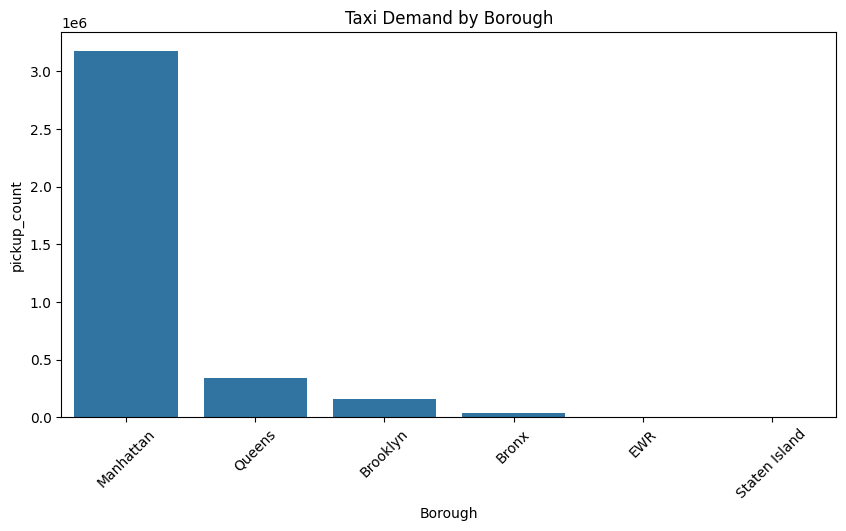

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=borough_demand, x="Borough", y="pickup_count")
plt.title("Taxi Demand by Borough")
plt.xticks(rotation=45)
plt.show()

This helps identify:

- Which borough dominates taxi demand
- City-level spatial imbalance

## Limitations of This Approach

- Centroids are synthetic, not real geographic coordinates
- No real road-level accuracy
- Cannot capture intra-zone variation
- Spatial distortion may exist

---

## Why this is still valid

✔ Zone-level analysis is industry standard  
✔ NYC taxi data is aggregated at zone level  
✔ This is sufficient for hotspot identification  